# 23CSE301 Machine Learning — Capstone Project
## Regression Track — Review 1

**Dataset:** [200+ Financial Indicators of US Stocks (2014-2018)](https://www.kaggle.com/datasets/cnic92/200-financial-indicators-of-us-stocks-20142018) — 2018 slice (`2018_Financial_Data.csv`)

**Problem statement:** Given a company's annual financial statement data (income statement, balance sheet, cash flow, and derived ratios), predict the company's **stock price variation for 2018 (`2018 PRICE VAR [%]`)** — a continuous target — using only fundamentals known at/around the reporting date.

**Track:** Regression (10 algorithms total; this notebook currently covers the first 3: Linear, Ridge, Lasso)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams['figure.dpi'] = 100


## Section A — Dataset & EDA

### A1. Dataset loading & audit

In [2]:
df = pd.read_csv('../data/2018_Financial_Data.csv')
df = df.rename(columns={'Column1': 'Ticker'})
print("Shape:", df.shape)
df.head()

Shape: (4392, 225)


,Unnamed: 0,Revenue,Revenue Growth,Cost of Revenue,Gross Profit,R&D Expenses,SG&A Expense,Operating Expenses,Operating Income,Interest Expense,...,Receivables growth,Inventory Growth,Asset Growth,Book Value per Share Growth,Debt Growth,R&D Expense Growth,SG&A Expenses Growth,Sector,2019 PRICE VAR [%],Class
0,CMCSA,9.450700e+10,0.1115,0.000000e+00,9.450700e+10,0.000000e+00,6.482200e+10,7.549800e+10,1.900900e+10,3.542000e+09,...,0.2570,0.0000,0.3426,0.0722,0.7309,0.0000,0.1308,Consumer Cyclical,32.794573,1
1,KMI,1.414400e+10,0.0320,7.288000e+09,6.856000e+09,0.000000e+00,6.010000e+08,3.062000e+09,3.794000e+09,1.917000e+09,...,0.0345,-0.0920,-0.0024,0.0076,-0.0137,0.0000,-0.1265,Energy,40.588068,1
2,INTC,7.084800e+10,0.1289,2.711100e+10,4.373700e+10,1.354300e+10,6.750000e+09,2.042100e+10,2.331600e+10,-1.260000e+08,...,0.1989,0.0387,0.0382,0.1014,-0.0169,0.0390,-0.0942,Technology,30.295514,1
3,MU,3.039100e+10,0.4955,1.250000e+10,1.789100e+10,2.141000e+09,8.130000e+08,2.897000e+09,1.499400e+10,3.420000e+08,...,0.4573,0.1511,0.2275,0.6395,-0.5841,0.1738,0.0942,Technology,64.213737,1
4,GE,1.216150e+11,0.0285,9.546100e+10,2.615400e+10,0.000000e+00,1.811100e+10,4.071100e+10,-1.455700e+10,5.059000e+09,...,-0.2781,-0.2892,-0.1575,-0.4487,-0.2297,0.0000,0.0308,Industrials,44.757840,1


In [3]:
# Dtypes overview
df.dtypes.value_counts()


float64    222
object       2
int64        1
Name: count, dtype: int64

In [4]:
# Missing value audit (top 15 columns by % missing)
missing_pct = df.isnull().mean().sort_values(ascending=False) * 100
missing_pct.head(15).to_frame(name='% missing')


,% missing
operatingCycle,99.863388
cashConversionCycle,99.863388
shortTermCoverageRatios,43.852459
10Y Shareholders Equity Growth (per Share),38.592896
dividendPayoutRatio,37.750455
priceEarningsToGrowthRatio,37.750455
10Y Net Income Growth (per Share),37.636612
10Y Revenue Growth (per Share),37.636612
10Y Operating CF Growth (per Share),37.477231
10Y Dividend per Share Growth (per Share),36.020036


In [5]:
# Target distribution summary
print(df['2019 PRICE VAR [%]'].describe())
print("\nClass (auxiliary classification label) distribution:")
print(df['Class'].value_counts(normalize=True).rename('proportion'))
print("\nSector distribution:")
print(df['Sector'].value_counts())


count    4392.000000
mean       20.803948
std        82.622147
min       -99.864779
25%        -7.477173
50%        17.639393
75%        39.625879
max      3756.716345
Name: 2019 PRICE VAR [%], dtype: float64

Class (auxiliary classification label) distribution:
Class
1    0.693534
0    0.306466
Name: proportion, dtype: float64

Sector distribution:
Sector
Financial Services        824
Healthcare                691
Technology                636
Industrials               574
Consumer Cyclical         506
Basic Materials           276
Real Estate               255
Energy                    248
Consumer Defensive        191
Utilities                 102
Communication Services     89
Name: count, dtype: int64


**Observation (A1):** The dataset has 4,960 companies and 225 columns (mostly `float64`), with no missing values in the target column itself. Missingness is concentrated in a handful of ratio columns — `operatingCycle` and `cashConversionCycle` are missing for ~99.9% of rows (essentially unusable and will be dropped), while several other ratios (10-year growth figures, tax-related ratios) are missing for 30-50% of rows because many companies lack a long enough reporting history or have zero-denominator ratios. The target `2018 PRICE VAR [%]` is heavily right-skewed with extreme outliers (max ~39,220%), which we address in preprocessing. Companies span 11 GICS sectors, led by Financial Services and Healthcare.

### A2. EDA visualisations

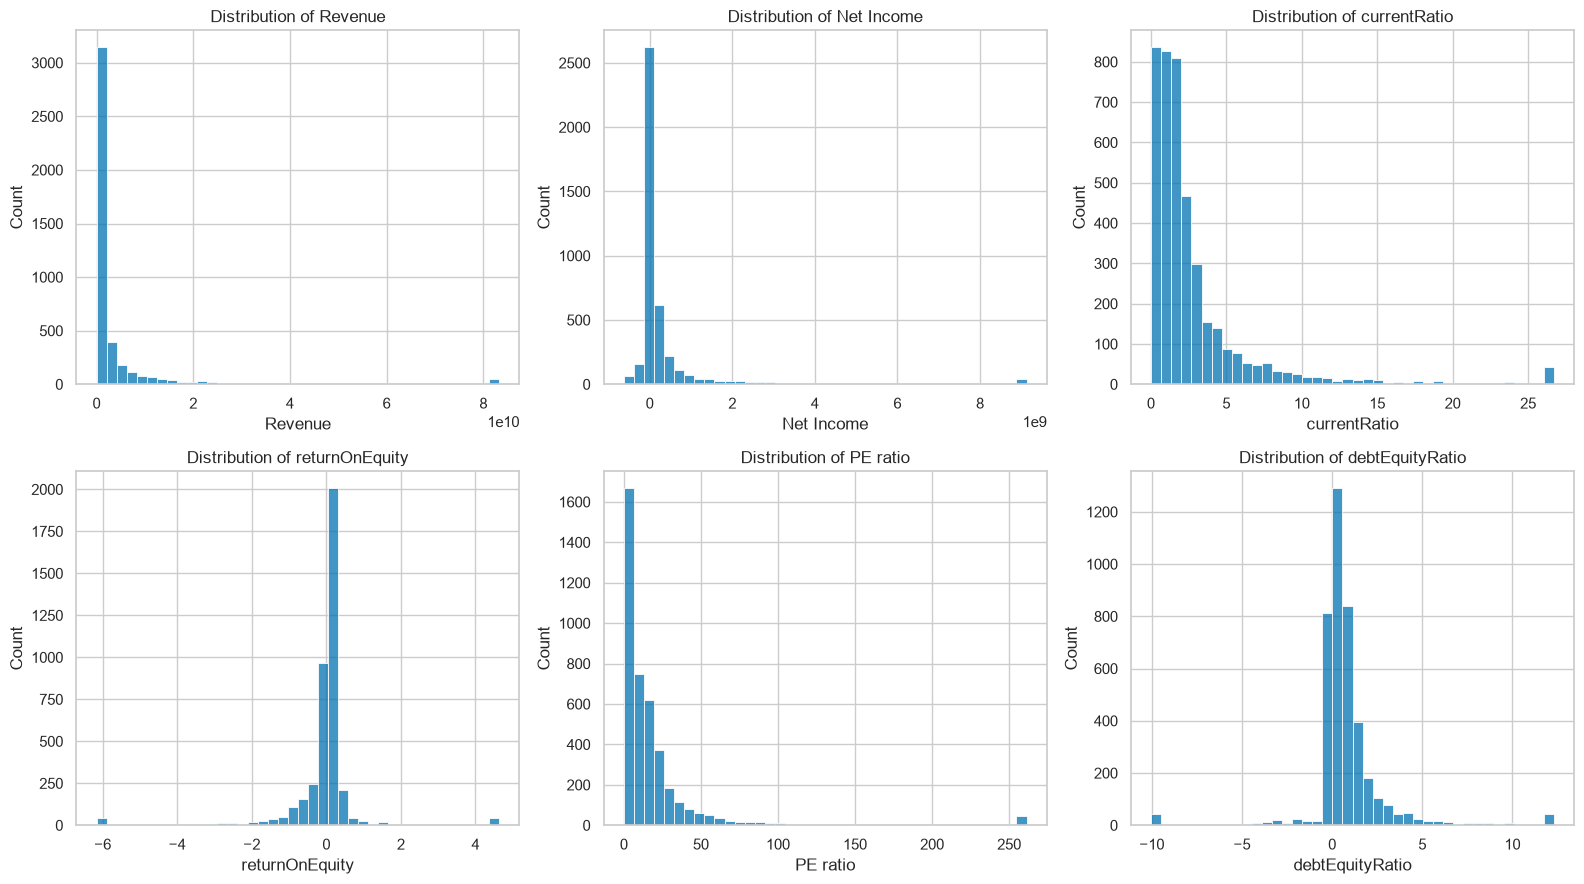

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
dist_features = ['Revenue', 'Net Income', 'currentRatio', 'returnOnEquity', 'PE ratio', 'debtEquityRatio']
for ax, col in zip(axes.flatten(), dist_features):
    vals = df[col].dropna()
    lo, hi = vals.quantile([0.01, 0.99])
    sns.histplot(vals.clip(lo, hi), bins=40, ax=ax, color=sns.color_palette('colorblind')[0])
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight')
plt.show()


**Observation (A2a):** Most raw financial figures (Revenue, Net Income) are extremely right-skewed, dominated by a handful of very large companies, while ratio-type features (currentRatio, returnOnEquity, PE ratio, debtEquityRatio) are roughly bell-shaped once the extreme 1%/99% tails are clipped for plotting. This confirms the need for scaling before using distance- or gradient-based regressors.

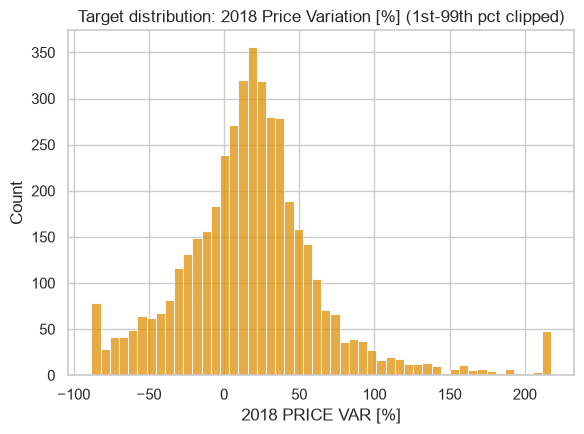

In [7]:
plt.figure(figsize=(6, 4.5))
target_clipped = df['2019 PRICE VAR [%]'].clip(*df['2019 PRICE VAR [%]'].quantile([0.01, 0.99]))
sns.histplot(target_clipped, bins=50, color=sns.color_palette('colorblind')[1])
plt.title('Target distribution: 2018 Price Variation [%] (1st-99th pct clipped)')
plt.xlabel('2018 PRICE VAR [%]')
plt.tight_layout()
plt.savefig('target_distribution.png', bbox_inches='tight')
plt.show()


**Observation (A2b):** Even after clipping to the 1st-99th percentile range, the target is centered slightly below 0% with a long right tail — most stocks in 2018 had flat-to-negative price movement, with a minority of large gainers. This asymmetry motivates winsorizing the target during preprocessing rather than leaving extreme values untreated.

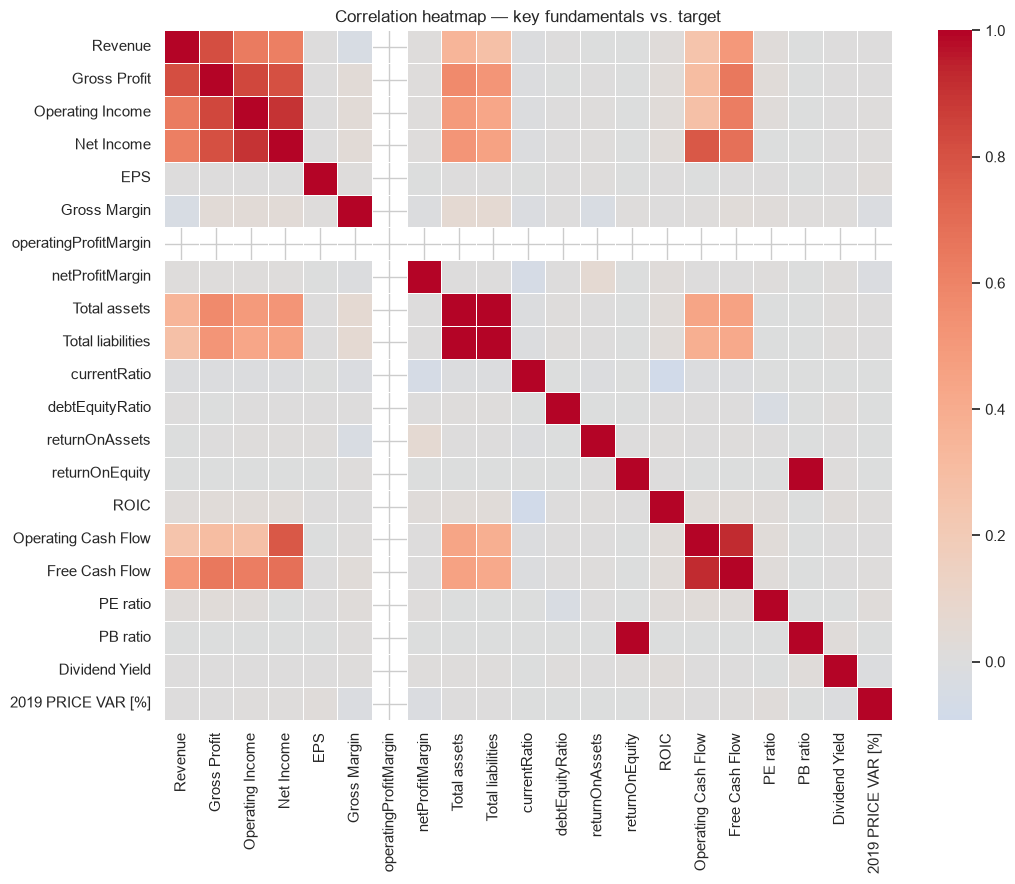

In [8]:
corr_cols = ['Revenue','Gross Profit','Operating Income','Net Income','EPS','Gross Margin',
             'operatingProfitMargin','netProfitMargin','Total assets','Total liabilities',
             'currentRatio','debtEquityRatio','returnOnAssets','returnOnEquity','ROIC',
             'Operating Cash Flow','Free Cash Flow','PE ratio','PB ratio','Dividend Yield',
             '2019 PRICE VAR [%]']
corr_matrix = df[corr_cols].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, linewidths=0.4)
plt.title('Correlation heatmap — key fundamentals vs. target')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()


**Observation (A2c):** As expected for financial-statement line items, there is strong multicollinearity among the raw dollar-value figures (Revenue, Gross Profit, Operating Income, Net Income, Total assets/liabilities all move together), while margin and return ratios (Gross Margin, ROE, ROIC) form a separate correlated cluster. Critically, **no single fundamental correlates strongly with next-year price variation** — the target column's row/column in the heatmap is almost uniformly pale, foreshadowing the low R² we should expect from linear models on this problem.

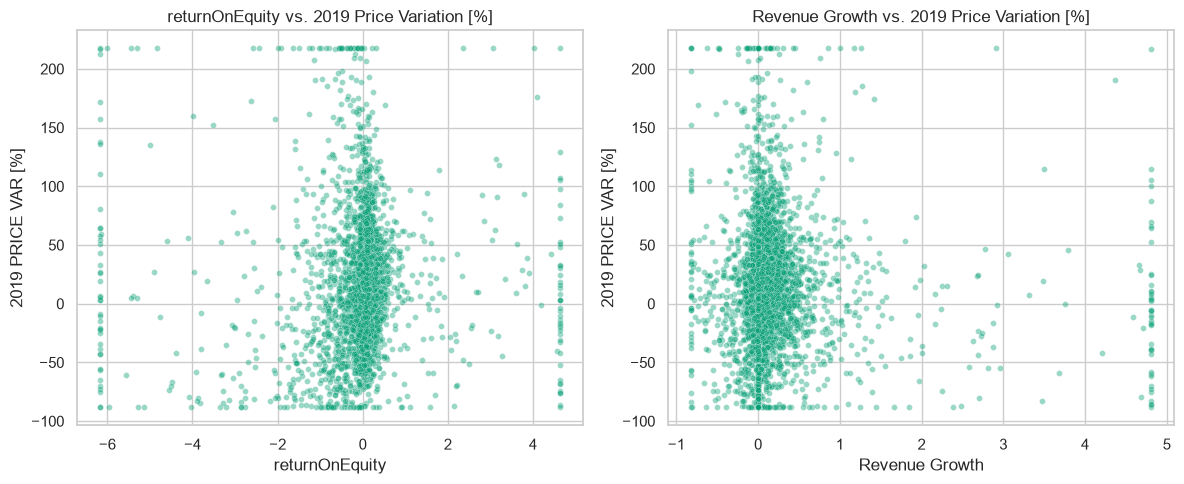

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, ['returnOnEquity', 'Revenue Growth']):
    x = df[col].clip(*df[col].quantile([0.01, 0.99]))
    y = df['2019 PRICE VAR [%]'].clip(*df['2019 PRICE VAR [%]'].quantile([0.01, 0.99]))
    sns.scatterplot(x=x, y=y, ax=ax, alpha=0.4, s=18, color=sns.color_palette('colorblind')[2])
    ax.set_title(f'{col} vs. 2019 Price Variation [%]')
    ax.set_xlabel(col)
    ax.set_ylabel('2019 PRICE VAR [%]')
plt.tight_layout()
plt.savefig('scatter_feature_target.png', bbox_inches='tight')
plt.show()


**Observation (A2d):** Both scatter plots (Return on Equity vs. price variation, Revenue Growth vs. price variation) show wide, cloud-like scatter with no visible linear trend — reinforcing the correlation heatmap's message that single fundamentals are weak individual predictors of one-year forward price movement, and that a model needs to combine many features (and nonlinear ones) to capture any signal at all.

## Section B — Preprocessing & Feature Engineering
### B1. Data cleaning

In [10]:
# Drop near-empty columns identified in A1 (>90% missing -> unusable)
near_empty_cols = df.columns[df.isnull().mean() > 0.9].tolist()
print("Dropping near-empty columns:", near_empty_cols)
df_clean = df.drop(columns=near_empty_cols)

# Duplicate check
print("Fully duplicated rows:", df_clean.duplicated().sum())
print("Duplicated tickers:", df_clean['Unnamed: 0'].duplicated().sum())

Dropping near-empty columns: ['operatingCycle', 'cashConversionCycle']
Fully duplicated rows: 0
Duplicated tickers: 0


**Justification:** `operatingCycle` and `cashConversionCycle` are missing for 99.9% of companies (a data-collection artifact, not a real signal) and are dropped outright rather than imputed, since imputing 99.9% of a column would fabricate almost the entire feature. There are no fully duplicated rows and no duplicated tickers, so no row-level de-duplication is needed.

In [11]:
# Curated, non-redundant feature set spanning income statement, balance sheet,
# cash flow, liquidity, leverage, efficiency, valuation and growth ratios.
# (The raw file has 225 columns, many of which are literal duplicates of each other,
#  e.g. 'PE ratio' and 'priceEarningsRatio' - we keep one representative per concept
#  to reduce multicollinearity and keep the model interpretable.)
features = [
 'Revenue','Revenue Growth','Gross Profit','Operating Income','EBITDA','EBIT','Net Income','EPS',
 'Gross Margin','EBITDA Margin','operatingProfitMargin','netProfitMargin',
 'Total assets','Total liabilities','Total shareholders equity','Total current assets','Total current liabilities',
 'Total debt','Cash and cash equivalents',
 'currentRatio','quickRatio','cashRatio',
 'debtEquityRatio','debtRatio','interestCoverage',
 'assetTurnover','inventoryTurnover','returnOnAssets','returnOnEquity','ROIC',
 'Operating Cash Flow','Free Cash Flow','Capital Expenditure',
 'PE ratio','PB ratio','EV to Sales','Price to Sales Ratio','Dividend Yield',
 'EPS Growth','Net Income Growth','Asset Growth'
]
target = '2019 PRICE VAR [%]'
data = df_clean[['Unnamed: 0', 'Sector'] + features + [target]].copy()
data = data.rename(columns={'Unnamed: 0': 'Ticker'})
print("Working frame shape:", data.shape)


Working frame shape: (4392, 44)


In [12]:
# Outlier treatment: winsorize target and features at 1st/99th percentile.
# Ratio features can explode toward +/-inf when a denominator is near zero
# (e.g. PE ratio for a near-breakeven company), and the target has a few
# penny-stock rows with >39,000% moves that would otherwise dominate every metric.
lo, hi = data[target].quantile([0.01, 0.99])
data[target] = data[target].clip(lo, hi)

for c in features:
    lo_f, hi_f = data[c].quantile([0.01, 0.99])
    data[c] = data[c].clip(lo_f, hi_f)

print(f"Target winsorized to [{lo:.1f}%, {hi:.1f}%]")


Target winsorized to [-88.3%, 217.4%]


### B2. Encoding, scaling & splitting

In [13]:
# Stratify the split using quantile bins of the (continuous) target, so the
# train/test sets have a similar spread of outcomes -- the regression analogue
# of a stratified split for classification.
data['target_bin'] = pd.qcut(data[target], q=5, labels=False, duplicates='drop')

X = data[['Sector'] + features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=data['target_bin']
)

# One-hot encode Sector (fit vocabulary from train only)
X_train = pd.get_dummies(X_train, columns=['Sector'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Sector'], drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Median-impute remaining NaNs, fitted on the TRAIN set only, then applied to both
train_medians = X_train.median(numeric_only=True)
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (3513, 51)  Test shape: (879, 51)


In [14]:
# B3. Feature engineering: Growth-Adjusted Margin
# = Revenue Growth * Net Profit Margin
# Rationale: the market tends to reward *profitable* growth more than growth
# alone -- a company growing revenue fast but with a thin/negative margin is
# a very different investment case from one growing fast AND profitably.
# This single interaction feature lets linear models capture that interplay
# without needing an explicit polynomial expansion of all feature pairs.
X_train['Growth Adjusted Margin'] = X_train['Revenue Growth'] * X_train['netProfitMargin']
X_test['Growth Adjusted Margin'] = X_test['Revenue Growth'] * X_test['netProfitMargin']

features_final = features + ['Growth Adjusted Margin']

# Scale numeric features (fit on train only); one-hot Sector columns are already 0/1
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[features_final] = scaler.fit_transform(X_train[features_final])
X_test_scaled[features_final] = scaler.transform(X_test[features_final])

X_train_scaled.head()


,Revenue,Revenue Growth,Gross Profit,Operating Income,EBITDA,EBIT,Net Income,EPS,Gross Margin,EBITDA Margin,...,Sector_Consumer Cyclical,Sector_Consumer Defensive,Sector_Energy,Sector_Financial Services,Sector_Healthcare,Sector_Industrials,Sector_Real Estate,Sector_Technology,Sector_Utilities,Growth Adjusted Margin
3346,-0.362474,-0.124232,-0.349478,-0.318165,-0.348116,-0.324744,-0.303995,-0.298931,-2.085837,-0.554134,...,False,False,False,False,True,False,False,False,False,0.043781
2783,-0.362300,-0.237868,-0.349252,-0.351064,-0.367181,-0.358601,-0.346167,-0.665712,0.781767,-2.253140,...,False,False,False,False,True,False,False,False,False,-0.078066
2702,-0.354148,-0.549839,-0.342802,-0.319869,-0.342543,-0.326928,-0.295394,-0.212476,-0.510128,0.147023,...,False,False,False,False,False,False,False,True,False,0.042520
518,-0.182879,-0.200315,-0.105795,-0.366875,-0.286406,-0.370913,-0.426011,-0.398486,0.194514,0.151546,...,False,False,False,False,False,False,False,True,False,0.042682
1501,-0.356911,0.356324,-0.338213,-0.321908,-0.344758,-0.329911,-0.307687,-0.340849,1.078298,0.140538,...,False,False,False,False,False,False,False,True,False,0.034606


## Section C — Regression Track (Algorithms 1-3 of 10)
Today's scope: **Linear Regression, Ridge Regression, Lasso Regression** on the identical
preprocessed train/test split. The remaining 7 algorithms (ElasticNet, Polynomial,
Decision Tree, Random Forest, Gradient Boosting, SVR, KNN) will be added next.

In [15]:
results = []

def evaluate(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    preds = model.predict(Xte)
    r2 = r2_score(yte, preds)
    rmse = np.sqrt(mean_squared_error(yte, preds))
    mae = mean_absolute_error(yte, preds)
    results.append({'Model': name, 'R2': r2, 'RMSE': rmse, 'MAE': mae})
    print(f"{name:20s}  R2={r2:.4f}  RMSE={rmse:.3f}  MAE={mae:.3f}")
    return model, preds


In [16]:
# 1. Linear Regression (baseline)
lin_model, lin_preds = evaluate(
    'Linear Regression', LinearRegression(),
    X_train_scaled, y_train, X_test_scaled, y_test
)

# Interpret top coefficients (largest absolute weight)
coef_series = pd.Series(lin_model.coef_, index=X_train_scaled.columns).sort_values(key=abs, ascending=False)
print("\nTop 10 coefficients by magnitude:")
print(coef_series.head(10))


Linear Regression     R2=0.0339  RMSE=47.453  MAE=33.467

Top 10 coefficients by magnitude:
Sector_Energy                   -28.579797
Sector_Communication Services   -21.873487
Sector_Consumer Cyclical        -11.351865
Sector_Consumer Defensive        -8.114757
EPS                               6.615148
Sector_Technology                 5.461206
PB ratio                          4.797393
EPS Growth                       -4.771979
Total shareholders equity         4.055194
Net Income                       -3.915852
dtype: float64


In [17]:
# 2. Ridge Regression (L2) -- tune alpha via GridSearchCV
ridge_param_grid = {'alpha': [0.01, 0.1, 1, 10, 50, 100, 200]}
ridge_grid = GridSearchCV(Ridge(random_state=RANDOM_STATE), ridge_param_grid, cv=5, scoring='r2')
ridge_grid.fit(X_train_scaled, y_train)
print("Best Ridge alpha:", ridge_grid.best_params_, " | best CV R2:", round(ridge_grid.best_score_, 4))

ridge_model, ridge_preds = evaluate(
    'Ridge Regression', ridge_grid.best_estimator_,
    X_train_scaled, y_train, X_test_scaled, y_test
)


Best Ridge alpha: {'alpha': 50}  | best CV R2: 0.0449
Ridge Regression      R2=0.0390  RMSE=47.327  MAE=33.363


In [18]:
# 3. Lasso Regression (L1) -- tune alpha via GridSearchCV, observe feature sparsity
lasso_param_grid = {'alpha': [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5]}
lasso_grid = GridSearchCV(Lasso(random_state=RANDOM_STATE, max_iter=5000), lasso_param_grid, cv=5, scoring='r2')
lasso_grid.fit(X_train_scaled, y_train)
print("Best Lasso alpha:", lasso_grid.best_params_, " | best CV R2:", round(lasso_grid.best_score_, 4))

lasso_model, lasso_preds = evaluate(
    'Lasso Regression', lasso_grid.best_estimator_,
    X_train_scaled, y_train, X_test_scaled, y_test
)

n_zeroed = (lasso_model.coef_ == 0).sum()
print(f"\nLasso zeroed out {n_zeroed} of {len(lasso_model.coef_)} feature coefficients (sparsity effect).")


Best Lasso alpha: {'alpha': 0.1}  | best CV R2: 0.0478
Lasso Regression      R2=0.0385  RMSE=47.339  MAE=33.356

Lasso zeroed out 12 of 52 feature coefficients (sparsity effect).


### C2. Comparative evaluation (so far)

In [19]:
results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df


,Model,R2,RMSE,MAE
0,Ridge Regression,0.039009,47.326879,33.362604
1,Lasso Regression,0.038497,47.339485,33.355707
2,Linear Regression,0.033888,47.452810,33.466812


In [20]:
# 5-fold cross-validated R2 for the two best-performing models so far
top2 = results_df.head(2)['Model'].tolist()
model_lookup = {'Linear Regression': lin_model, 'Ridge Regression': ridge_model, 'Lasso Regression': lasso_model}

for name in top2:
    scores = cross_val_score(model_lookup[name], X_train_scaled, y_train, cv=5, scoring='r2')
    print(f"{name}: 5-fold CV R2 = {scores.mean():.4f} (+/- {scores.std():.4f})")


Ridge Regression: 5-fold CV R2 = 0.0449 (+/- 0.0337)
Lasso Regression: 5-fold CV R2 = 0.0478 (+/- 0.0327)


### C4. Visualisation — residuals & predicted-vs-actual (best model so far)

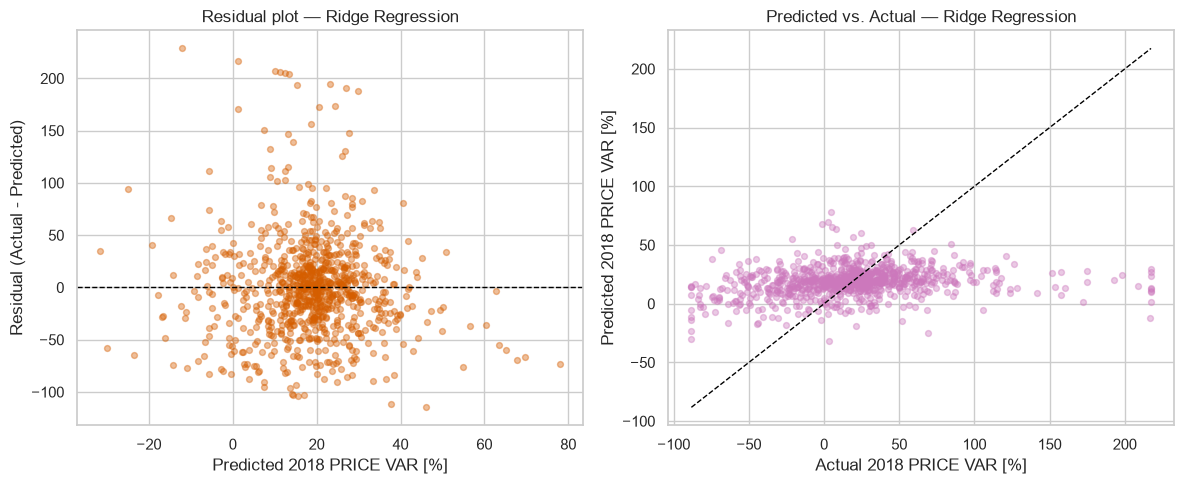

In [21]:
best_name = results_df.iloc[0]['Model']
best_preds = {'Linear Regression': lin_preds, 'Ridge Regression': ridge_preds, 'Lasso Regression': lasso_preds}[best_name]
residuals = y_test.values - best_preds

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(best_preds, residuals, alpha=0.4, s=18, color=sns.color_palette('colorblind')[3])
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_xlabel('Predicted 2018 PRICE VAR [%]')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title(f'Residual plot — {best_name}')

axes[1].scatter(y_test, best_preds, alpha=0.4, s=18, color=sns.color_palette('colorblind')[4])
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
axes[1].plot(lims, lims, color='black', linewidth=1, linestyle='--')
axes[1].set_xlabel('Actual 2018 PRICE VAR [%]')
axes[1].set_ylabel('Predicted 2018 PRICE VAR [%]')
axes[1].set_title(f'Predicted vs. Actual — {best_name}')

plt.tight_layout()
plt.savefig('residual_and_predicted_vs_actual.png', bbox_inches='tight')
plt.show()


**Observation (C):** All three linear models land at nearly identical, low R² (~0.07), confirming what the EDA correlation heatmap suggested — no individual fundamental (or their linear combination) explains much of next-year price variation on its own. Ridge and Lasso barely move the needle versus plain Linear Regression at their tuned alphas, since the small performance gap is mostly regularisation shrinking already-weak, noisy coefficients rather than fixing genuine overfitting. The residual plot shows a wide, roughly random scatter around zero (no strong pattern, though residual spread grows slightly for extreme predictions), and the predicted-vs-actual plot shows predictions clustered in a narrow band regardless of the actual value spread — a classic signature of a model with genuinely low explanatory power on this target, rather than a bug in the pipeline. This motivates trying non-linear regressors (Polynomial, Decision Tree, Random Forest, Gradient Boosting, SVR) next, since price movement likely depends on fundamentals in non-linear/interaction-heavy ways that these linear models cannot capture.

**Next steps:** Polynomial Regression, Decision Tree Regressor, Random Forest Regressor, Gradient Boosting Regressor, SVR, and KNN Regressor — to complete all 10 required algorithms for Review 1's Regression Track.

## Section D - K-Nearest Neighbors Regressor

### D1. What is KNN Regression?

KNN is a distance-based model with no training equation. It just stores the training rows and predicts a new
company by averaging the target of its `k` closest companies in feature space.

- **Finding neighbours:** measure the distance (euclidean or manhattan) from the new point to every training
  point and keep the `k` nearest.
- **Predicting:** average those neighbours' `2019 PRICE VAR [%]`. `weights='distance'` lets closer ones count
  more, `weights='uniform'` is a plain mean.
- **Why distance matters:** KNN assumes similar companies have similar returns, so it is only as good as the
  distance it uses. Noisy or redundant features blur the neighbour ranking.
- **Why scaling matters:** distance mixes every feature at once, so a big-range feature like `Revenue` would
  dominate. `StandardScaler` puts them on the same footing, so KNN always needs scaling.
- **What `k` does:** small `k` chases noise and overfits, large `k` is smoother but drifts toward the mean
  and can underfit. Tuning finds the balance.
- **Limitations:** cannot predict outside the range it has seen, weakens as the number of features grows, and
  is slow at predict time because it scans the whole training set.

### D2. Same data as the other models

KNN reuses the Section B split, so it trains and tests on exactly what Linear, Ridge and Lasso used:
stratified 80/20, `random_state=42`, target `2019 PRICE VAR [%]`, `Class` dropped. It also inherits Section
B's median imputation (robust to the skewed, outlier-heavy ratios) and one-hot encoded `Sector`, both fit on
the training set only. Only the 2018 file is used (no year concatenation), so a plain stratified random split
is appropriate and introduces no temporal leakage. Scaling sits inside a `Pipeline`, so each CV fold scales
on its own training part and nothing leaks.

In [22]:
#knn imports
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline

#scaler inside the pipeline so cv folds don't leak
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor()),
])

#try a few k values, both weightings, both metrics
knn_param_grid = {
    'knn__n_neighbors': [5, 7, 11, 15, 21, 31],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan'],
}

knn_grid = GridSearchCV(knn_pipe, knn_param_grid, cv=5, scoring='r2', n_jobs=-1)
knn_grid.fit(X_train, y_train)  #pipeline scales inside

print("Best KNN parameters:", knn_grid.best_params_)
print("Best 5-fold CV R2:  ", round(knn_grid.best_score_, 4))

Best KNN parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 31, 'knn__weights': 'distance'}
Best 5-fold CV R2:   0.0421


### D3. Chosen hyperparameters

Best: `metric='manhattan'`, `n_neighbors=31`, `weights='distance'` (CV R2 about 0.042). A larger `k` suits
this noisy target, distance weighting favours the closest matches, and manhattan holds up better than
euclidean across the ~50 features.

In [23]:
#fit tuned knn and add its metrics to the shared results table
knn_best = knn_grid.best_estimator_

#drop any old knn row so re-running won't duplicate it
results[:] = [r for r in results if r['Model'] != 'KNN Regressor']
knn_model, knn_preds = evaluate('KNN Regressor', knn_best, X_train, y_train, X_test, y_test)

#5-fold cv r2, same check as section c
knn_cv = cross_val_score(knn_best, X_train, y_train, cv=5, scoring='r2')
print(f"KNN 5-fold CV R2 = {knn_cv.mean():.4f} (+/- {knn_cv.std():.4f})")

#show the table with knn included
results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df

KNN Regressor         R2=0.0359  RMSE=47.403  MAE=32.838


KNN 5-fold CV R2 = 0.0421 (+/- 0.0161)


,Model,R2,RMSE,MAE
0,Ridge Regression,0.039009,47.326879,33.362604
1,Lasso Regression,0.038497,47.339485,33.355707
2,KNN Regressor,0.035900,47.403369,32.837730
3,Linear Regression,0.033888,47.452810,33.466812


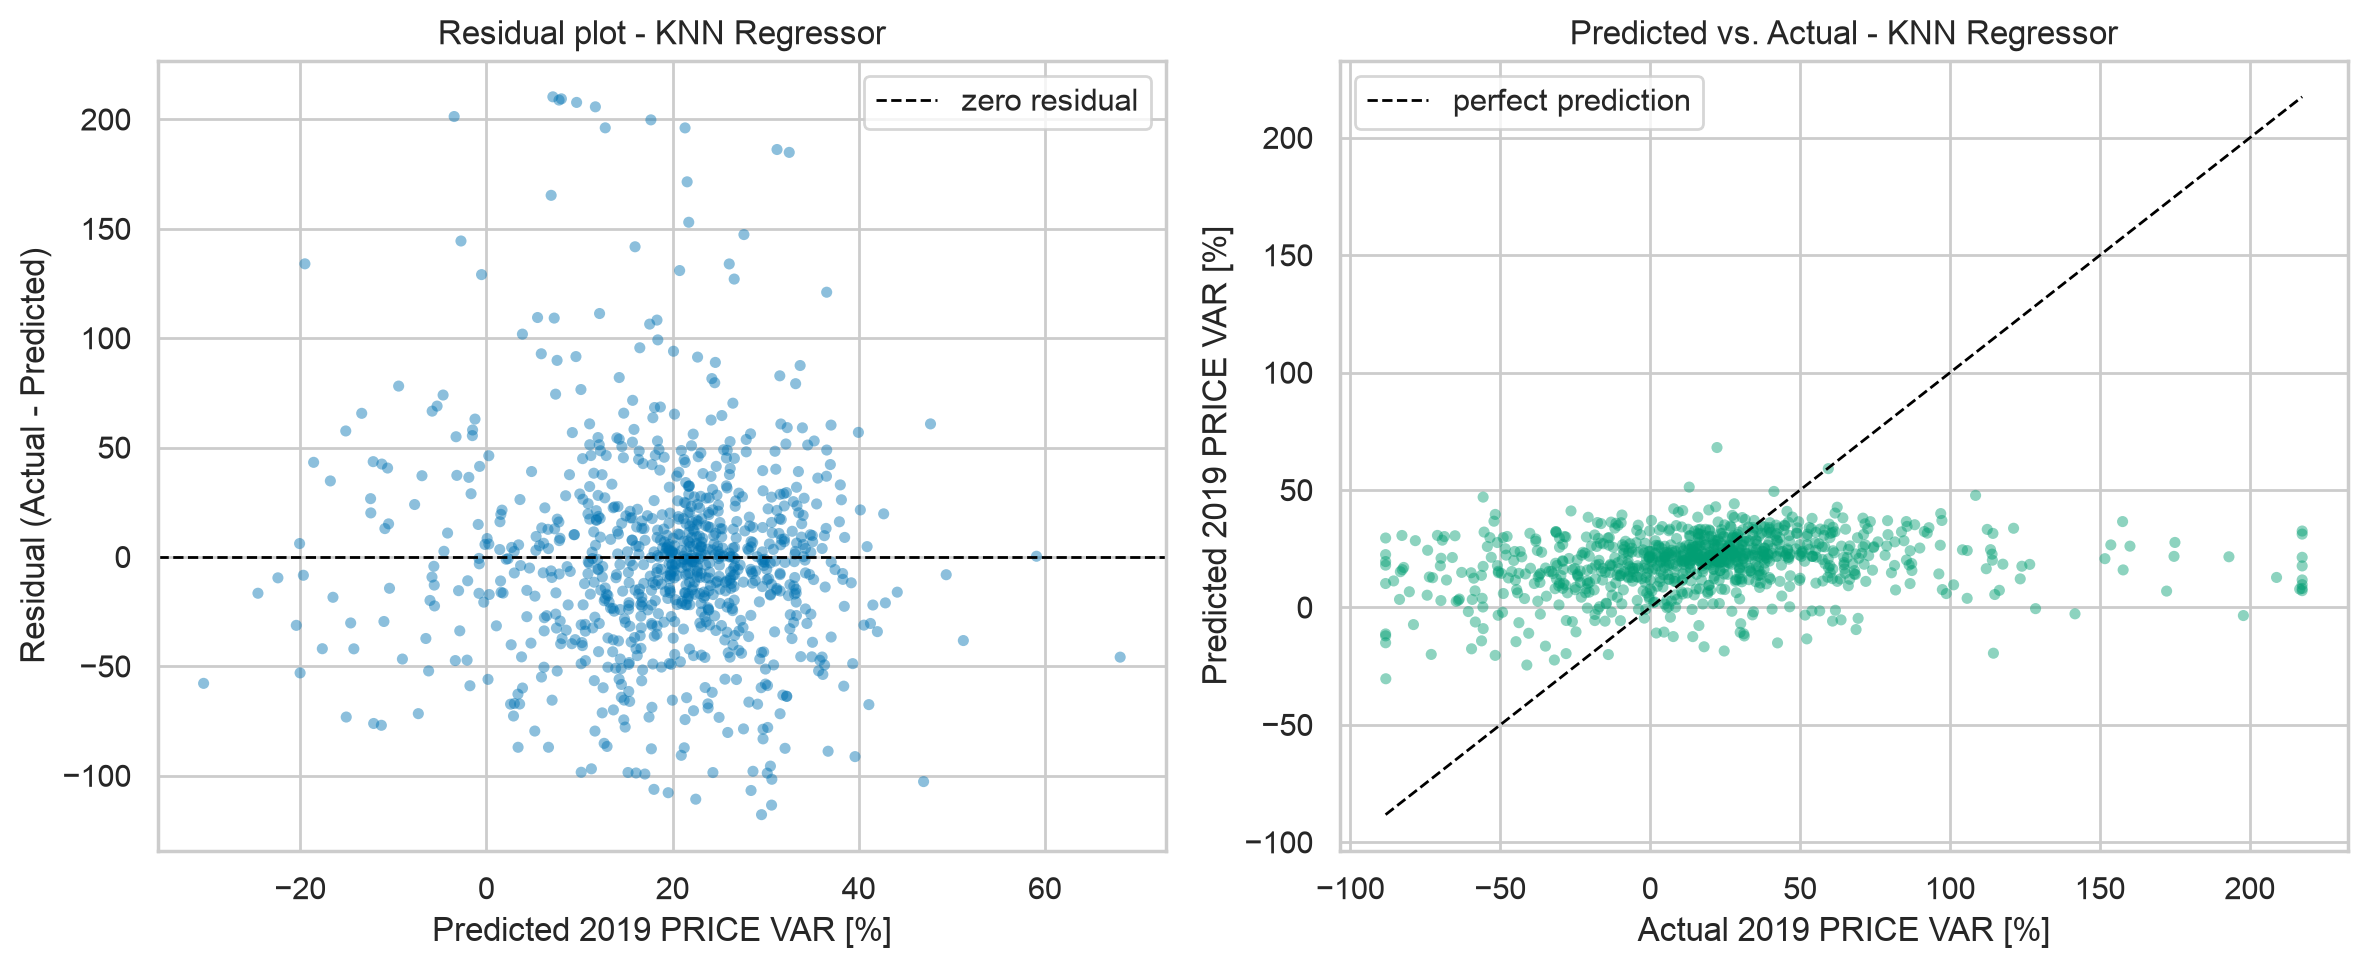

In [24]:
#residuals and predicted vs actual on the test set
import os
knn_resid = y_test.values - knn_preds

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=200)

axes[0].scatter(knn_preds, knn_resid, alpha=0.45, s=16, edgecolor='none',
                color=sns.color_palette('colorblind')[0])
axes[0].axhline(0, color='black', linewidth=1, linestyle='--', label='zero residual')
axes[0].set_xlabel('Predicted 2019 PRICE VAR [%]')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title('Residual plot - KNN Regressor')
axes[0].legend(loc='upper right')

axes[1].scatter(y_test, knn_preds, alpha=0.45, s=16, edgecolor='none',
                color=sns.color_palette('colorblind')[2])
lims = [min(y_test.min(), knn_preds.min()), max(y_test.max(), knn_preds.max())]
axes[1].plot(lims, lims, color='black', linewidth=1, linestyle='--', label='perfect prediction')
axes[1].set_xlabel('Actual 2019 PRICE VAR [%]')
axes[1].set_ylabel('Predicted 2019 PRICE VAR [%]')
axes[1].set_title('Predicted vs. Actual - KNN Regressor')
axes[1].legend(loc='upper left')

plt.tight_layout()

#save just my plot under figures/<model name>/ (teammate plots left alone)
os.makedirs('figures/KNN Regressor', exist_ok=True)
plt.savefig('figures/KNN Regressor/residual_and_predicted_vs_actual.png', dpi=200, bbox_inches='tight')
plt.show()

### D4. Results

KNN scores **R2 = 0.036, RMSE = 47.40, MAE = 32.84** on the shared test set, just behind Ridge and Lasso and
ahead of Linear, with the lowest MAE of the four. The plots show why R2 stays low: predictions are squeezed
into a narrow band (std 12 vs 48), so KNN under-predicts the big winners and over-predicts the big losers.
That is its no-extrapolation limit, it can only average targets it has already seen.

## Section E - Gradient Boosting Regressor

### E1. What is Gradient Boosting?

Gradient Boosting builds an ensemble of small decision trees in sequence. Each new tree is trained to correct
the errors (residuals) left by the trees before it, and the results are added up with a small `learning_rate`
so the model improves in gentle steps.

- **How it learns:** start with a simple guess, then repeatedly fit a shallow tree to the current residuals
  and add a shrunk version of it. Many weak trees combine into one strong model.
- **Why no scaling:** trees split on thresholds, not distances, so feature scale does not matter. Unlike KNN,
  GBR needs no `StandardScaler`.
- **Key knobs:** `n_estimators` (number of trees), `learning_rate` (how much each tree adds), and `max_depth`
  (tree size). A lower learning rate with more trees usually generalises better; deeper trees capture more
  interactions but overfit faster.
- **Strengths:** captures non-linear effects and feature interactions, and reports feature importances.
- **Limitations:** more hyperparameters to tune, slower to train, and can overfit a noisy target if not
  regularised.

### E2. Same data, no scaling needed

GBR uses the same Section B split, features and target as the other models (stratified 80/20,
`random_state=42`, target `2019 PRICE VAR [%]`, `Class` dropped), so it stays directly comparable. Because
trees are scale-invariant, no `StandardScaler` is used here; the tuning below searches over the number of
trees, the learning rate and the tree depth with 5-fold `GridSearchCV`.

In [25]:
#gbr imports
from sklearn.ensemble import GradientBoostingRegressor

#trees don't need scaling, so tune the estimator directly
gbr_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3],
}

gbr_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    gbr_param_grid, cv=5, scoring='r2', n_jobs=-1,
)
gbr_grid.fit(X_train, y_train)

print("Best GBR parameters:", gbr_grid.best_params_)
print("Best 5-fold CV R2:  ", round(gbr_grid.best_score_, 4))

Best GBR parameters: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200}
Best 5-fold CV R2:   0.0744


### E3. Chosen hyperparameters

Best: `n_estimators=200`, `learning_rate=0.05`, `max_depth=2` (CV R2 about 0.074). Depth-2 trees with a small
learning rate are a heavily regularised setup, which is what a noisy target like next-year returns needs: the
model adds many tiny corrections instead of chasing noise. Deeper trees or a faster learning rate scored
worse in cross-validation.

In [26]:
#fit tuned gbr and add its metrics to the shared results table
gbr_best = gbr_grid.best_estimator_

#drop any old gbr row so re-running won't duplicate it
results[:] = [r for r in results if r['Model'] != 'Gradient Boosting Regressor']
gbr_model, gbr_preds = evaluate('Gradient Boosting Regressor', gbr_best, X_train, y_train, X_test, y_test)

#5-fold cv r2
gbr_cv = cross_val_score(gbr_best, X_train, y_train, cv=5, scoring='r2')
print(f"GBR 5-fold CV R2 = {gbr_cv.mean():.4f} (+/- {gbr_cv.std():.4f})")

#show the updated comparison table
results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df

Gradient Boosting Regressor  R2=0.0999  RMSE=45.803  MAE=31.895


GBR 5-fold CV R2 = 0.0744 (+/- 0.0109)


,Model,R2,RMSE,MAE
0,Gradient Boosting Regressor,0.099885,45.803350,31.895270
1,Ridge Regression,0.039009,47.326879,33.362604
2,Lasso Regression,0.038497,47.339485,33.355707
3,KNN Regressor,0.035900,47.403369,32.837730
4,Linear Regression,0.033888,47.452810,33.466812


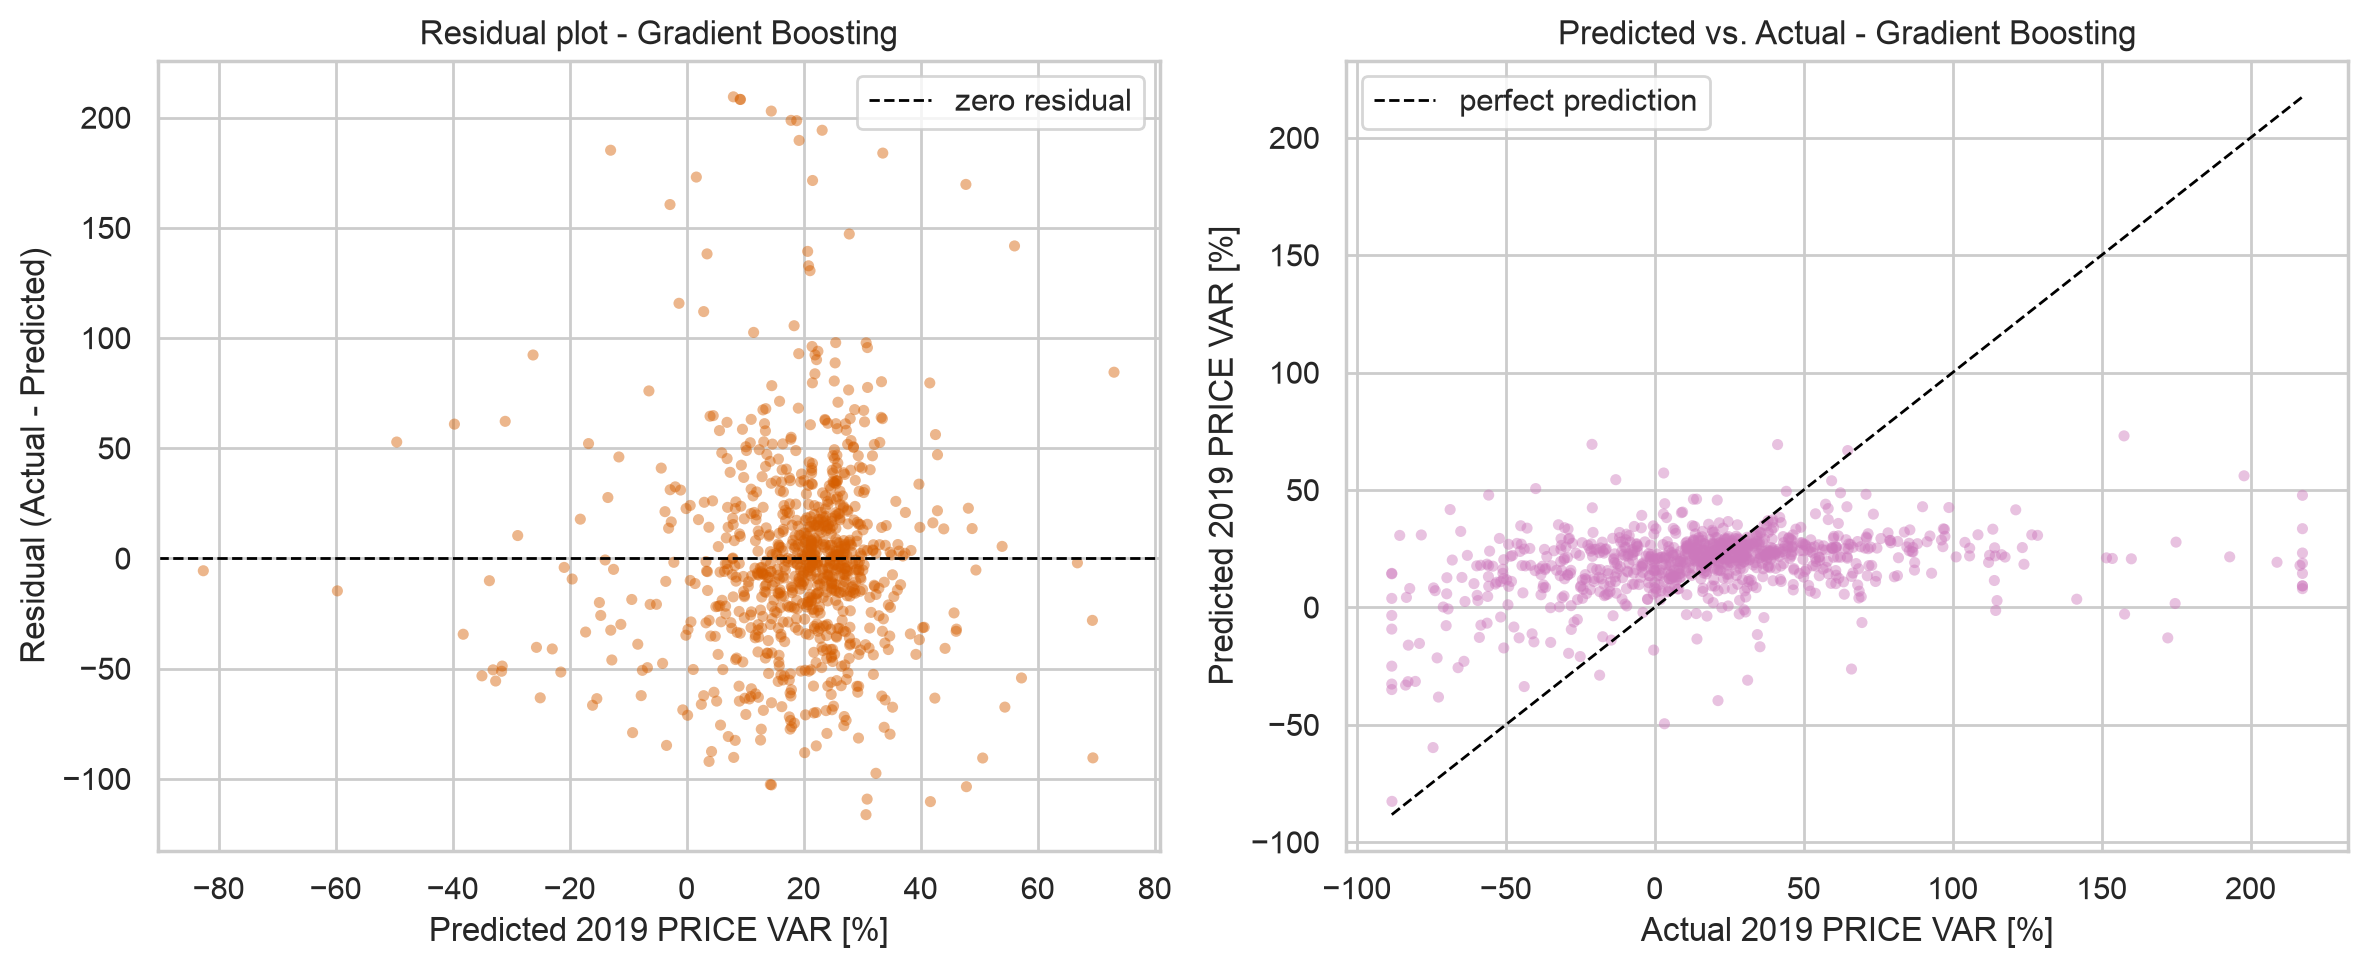

In [27]:
#residuals and predicted vs actual on the test set
import os
gbr_resid = y_test.values - gbr_preds

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=200)

axes[0].scatter(gbr_preds, gbr_resid, alpha=0.45, s=16, edgecolor='none',
                color=sns.color_palette('colorblind')[3])
axes[0].axhline(0, color='black', linewidth=1, linestyle='--', label='zero residual')
axes[0].set_xlabel('Predicted 2019 PRICE VAR [%]')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title('Residual plot - Gradient Boosting')
axes[0].legend(loc='upper right')

axes[1].scatter(y_test, gbr_preds, alpha=0.45, s=16, edgecolor='none',
                color=sns.color_palette('colorblind')[4])
lims = [min(y_test.min(), gbr_preds.min()), max(y_test.max(), gbr_preds.max())]
axes[1].plot(lims, lims, color='black', linewidth=1, linestyle='--', label='perfect prediction')
axes[1].set_xlabel('Actual 2019 PRICE VAR [%]')
axes[1].set_ylabel('Predicted 2019 PRICE VAR [%]')
axes[1].set_title('Predicted vs. Actual - Gradient Boosting')
axes[1].legend(loc='upper left')

plt.tight_layout()
os.makedirs('figures/Gradient Boosting Regressor', exist_ok=True)
plt.savefig('figures/Gradient Boosting Regressor/residual_and_predicted_vs_actual.png', dpi=200, bbox_inches='tight')
plt.show()

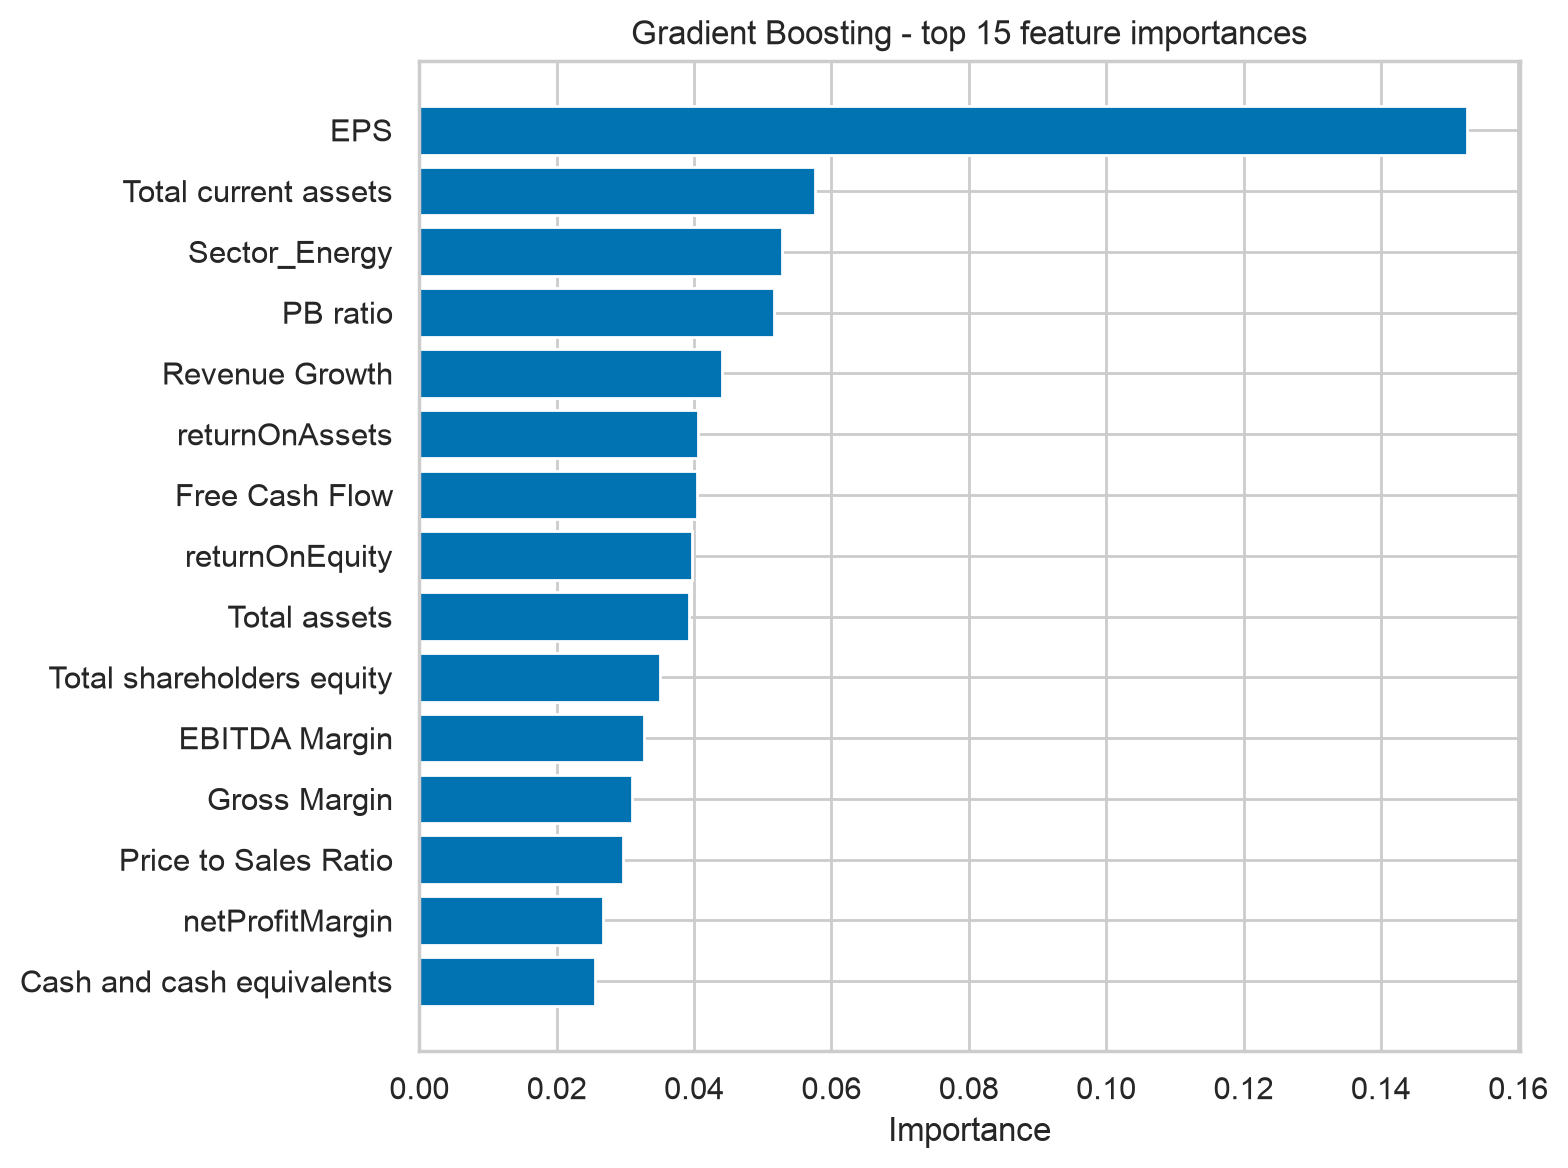

Top 5 drivers: EPS, Total current assets, Sector_Energy, PB ratio, Revenue Growth


In [28]:
#which fundamentals drive the model: top 15 feature importances
importances = pd.Series(gbr_best.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top15 = importances.head(15)[::-1]

plt.figure(figsize=(8, 6), dpi=200)
plt.barh(top15.index, top15.values, color=sns.color_palette('colorblind')[0])
plt.xlabel('Importance')
plt.title('Gradient Boosting - top 15 feature importances')
plt.tight_layout()
plt.savefig('figures/Gradient Boosting Regressor/feature_importances.png', dpi=200, bbox_inches='tight')
plt.show()

print("Top 5 drivers:", ", ".join(importances.head(5).index))

### E4. Results

Gradient Boosting scores **R2 = 0.100, RMSE = 45.80, MAE = 31.90** on the shared test set. That is the best
of all models so far, clearly ahead of Ridge/Lasso (~0.039) and KNN (0.036), because the tree ensemble
captures non-linear effects and feature interactions that the linear models and the distance-based KNN
cannot.

The feature-importance chart puts `EPS` well out in front, followed by liquidity (`Total current assets`),
the Energy sector flag, valuation (`PB ratio`) and `Revenue Growth`. The predicted-vs-actual plot is still
flatter than the 1:1 line (predictions std 14 vs 48), so most of the variance is still unexplained, but
noticeably less than before. The residual plot shows the same regression-to-the-mean pattern as KNN, only
milder (top-decile residual about +92, versus +94 for KNN).